/tmp/ipykernel_2569/1095802788.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download('^NSEI', start = '2015-01-01', end = '2026-01-01', progress = False)


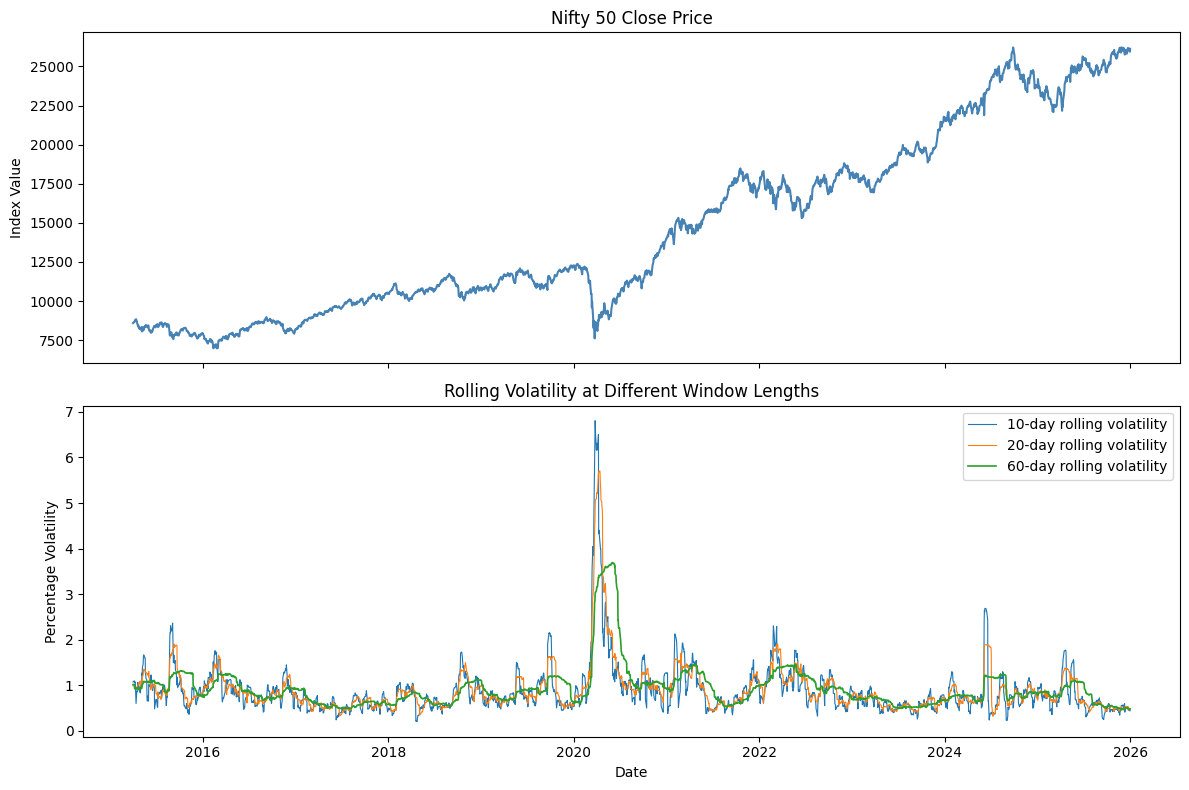

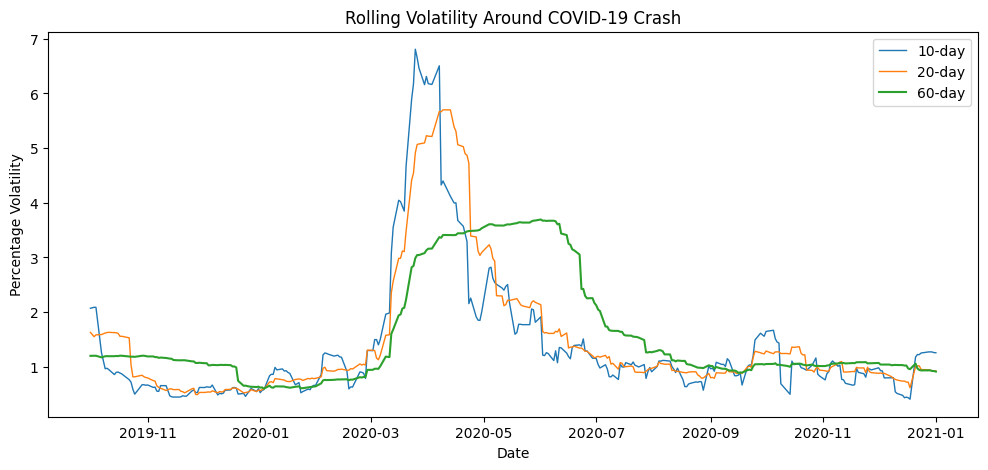

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#data download
nifty = yf.download('^NSEI', start = '2015-01-01', end = '2026-01-01', progress = False)
#clean
if isinstance(nifty.columns, pd.MultiIndex):
  nifty.columns = nifty.columns.droplevel(1)
nifty = nifty.dropna()
#compute log returns
nifty['log_return'] = 100 * np.log(nifty['Close']/nifty['Close'].shift(1))
nifty = nifty.dropna()
#compute rolling standard deviation (volatility)
nifty['vol_10d'] = nifty['log_return'].rolling(10).std()
nifty['vol_20d'] = nifty['log_return'].rolling(20).std()
nifty['vol_60d'] = nifty['log_return'].rolling(60).std()
nifty = nifty.dropna()

#plot rolling volatility
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(nifty.index, nifty['Close'], color='steelblue')
axes[0].set_title('Nifty 50 Close Price')
axes[0].set_ylabel('Index Value')

axes[1].plot(nifty.index, nifty['vol_10d'], label='10-day rolling volatility', linewidth=0.8)
axes[1].plot(nifty.index, nifty['vol_20d'], label='20-day rolling volatility', linewidth=0.8)
axes[1].plot(nifty.index, nifty['vol_60d'], label='60-day rolling volatility', linewidth=1.2)
axes[1].set_title('Rolling Volatility at Different Window Lengths')
axes[1].set_ylabel('Percentage Volatility')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

#plot crisis rolling volatility for comparison
covid_window = nifty.loc['2019-10-01':'2021-01-01']

plt.figure(figsize=(12, 5))
plt.plot(covid_window.index, covid_window['vol_10d'], label='10-day', linewidth=1)
plt.plot(covid_window.index, covid_window['vol_20d'], label='20-day', linewidth=1)
plt.plot(covid_window.index, covid_window['vol_60d'], label='60-day', linewidth=1.5)
plt.title('Rolling Volatility Around COVID-19 Crash')
plt.ylabel('Percentage Volatility')
plt.xlabel('Date')
plt.legend()
plt.show()

